<a href="https://colab.research.google.com/github/aanyaaroshree/BERT/blob/main/Fake_News_BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4


In [3]:
!pip install -q transformers datasets evaluate accelerate shap scikit-learn pandas numpy matplotlib seaborn

In [4]:
import torch
import pandas as pd
import numpy as np

print("PyTorch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())


PyTorch: 2.11.0+cu128
GPU available: True


In [5]:
true_df = pd.read_csv("/kaggle/True.csv")
fake_df = pd.read_csv("/kaggle/Fake.csv")

print(true_df.shape)
print(fake_df.shape)

print(true_df.head())
print(fake_df.head())

print(true_df.columns)
print(fake_df.columns)

(21417, 4)
(23481, 4)
                                               title  \
0  As U.S. budget fight looms, Republicans flip t...   
1  U.S. military to accept transgender recruits o...   
2  Senior U.S. Republican senator: 'Let Mr. Muell...   
3  FBI Russia probe helped by Australian diplomat...   
4  Trump wants Postal Service to charge 'much mor...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   
3  WASHINGTON (Reuters) - Trump campaign adviser ...  politicsNews   
4  SEATTLE/WASHINGTON (Reuters) - President Donal...  politicsNews   

                 date  
0  December 31, 2017   
1  December 29, 2017   
2  December 31, 2017   
3  December 30, 2017   
4  December 29, 2017   
                                               title  \
0   Donald Trump Sen

In [6]:
true_df["label"] = 0
fake_df["label"] = 1
df = pd.concat(
    [true_df, fake_df],
    ignore_index=True
)

print(df.shape)

(44898, 5)


title      0
text       0
subject    0
date       0
label      0
dtype: int64
label
0    21196
1    17462
Name: count, dtype: int64


<Axes: title={'center': 'Class Distribution'}, xlabel='label'>

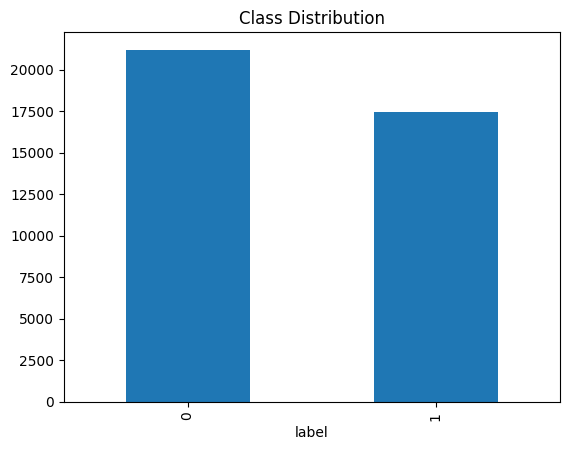

In [7]:
#Keep only what BERT needs
print(df.isnull().sum())
#Check for missing values
df = df.dropna(subset=["title", "text"])
df = df[
    (df["title"].str.strip() != "") &
    (df["text"].str.strip() != "")
]
#drop duplicates
df = df.drop_duplicates(
    subset=["title", "text"]
).reset_index(drop=True)
#shuffle
df = df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)
#Check class distribution
print(df["label"].value_counts())
df["label"].value_counts().plot(
    kind="bar",
    title="Class Distribution"
)

In [9]:
#Combine title and body
df["input_text"] = (
    df["title"].fillna("") +
    " " +
    df["text"].fillna("")
)


In [10]:
#Split the dataset 70% training 15% Validation 15% testing

from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print(len(train_df))
print(len(val_df))
print(len(test_df))

27060
5799
5799


In [11]:
#Load BERT
from transformers import AutoTokenizer, AutoModelForSequenceClassification
model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [17]:
#Tokenize your datasets
from datasets import Dataset

train_dataset = Dataset.from_pandas(
    train_df[["input_text", "label"]]
)

val_dataset = Dataset.from_pandas(
    val_df[["input_text", "label"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["input_text", "label"]]
)

In [18]:
#Tokenization function
def tokenize_function(examples):
    return tokenizer(
        examples["input_text"],
        truncation=True,
        max_length=512
    )
tokenized_train = train_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_val = val_dataset.map(
    tokenize_function,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize_function,
    batched=True
)


Map:   0%|          | 0/27060 [00:00<?, ? examples/s]

Map:   0%|          | 0/5799 [00:00<?, ? examples/s]

Map:   0%|          | 0/5799 [00:00<?, ? examples/s]

In [19]:
#Rename label correctly
tokenized_train = tokenized_train.rename_column(
    "label", "labels"
)

tokenized_val = tokenized_val.rename_column(
    "label", "labels"
)

tokenized_test = tokenized_test.rename_column(
    "label", "labels"
)
#Remove unnecessary columns
tokenized_train = tokenized_train.remove_columns(
    ["input_text"]
)

tokenized_val = tokenized_val.remove_columns(
    ["input_text"]
)

tokenized_test = tokenized_test.remove_columns(
    ["input_text"]
)


In [20]:
#Dyanamic Padding
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)
#Define your metrics
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support
)

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="binary"
        )
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }
